# Neural Network For Handwritten Digit Recognition Using PyTorch

## Importing Essential Packages

In [38]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from PIL import Image


## Checking GPU compatibility

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [9]:
transform = transforms.ToTensor()

## Checking Dataset

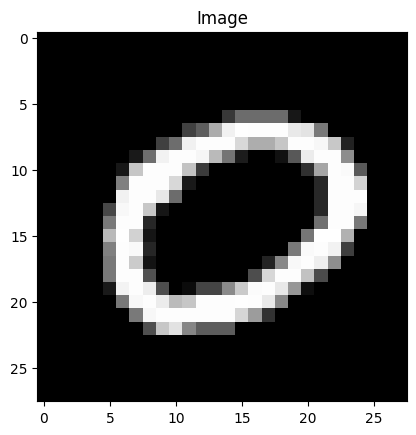

In [37]:
showImage = Image.open('../data/mnistmini/training/0/11654.png')

plt.title("Image")
plt.imshow(showImage, cmap = "gray")
plt.show()

## Loading and Transforming into Tensors

In [15]:
train_data = datasets.ImageFolder(
    root = '../data/mnistmini/training',
    transform = transform
)

test_data = datasets.ImageFolder(
    root = "../data/mnistmini/testing",
    transform = transform
)

In [17]:
train_loader = DataLoader(train_data, batch_size = 64, shuffle = True)
test_loader = DataLoader(test_data, batch_size = 64, shuffle = True)

In [20]:
print("Classes (train): ", train_data.classes)
print("Classes (test): ", test_data.classes)
print("Train Size: ", len(train_data))
print("Test Size: ", len(test_data))

Classes (train):  ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Classes (test):  ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Train Size:  1000
Test Size:  200


## Model Creation

In [ ]:
class DigitModel(nn.Module):

    def __init__(self):
        super(DigitModel, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        x = self.fc3(x)

        return x


In [44]:
model = DigitModel().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

In [45]:
epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        preds = model(images)
        loss = criterion(preds, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f'Epochs: {epoch + 1}, Loss: {running_loss/len(train_loader):.4f}')


Epochs: 1, Loss: 1.9566
Epochs: 2, Loss: 1.0226
Epochs: 3, Loss: 0.5677
Epochs: 4, Loss: 0.3938
Epochs: 5, Loss: 0.3229
Epochs: 6, Loss: 0.2542
Epochs: 7, Loss: 0.2141
Epochs: 8, Loss: 0.1881
Epochs: 9, Loss: 0.1402
Epochs: 10, Loss: 0.1196
